In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from PIL import Image
from utils import load_your_model
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve

In [ ]:
CLASSES = ['NORMAL', 'PNEUMONIA']
CSV_PATH= './dataset.csv'

In [ ]:
df= pd.read_csv(CSV_PATH)
df.info()

In [ ]:
df.head()

In [ ]:
model, config, preprocess= load_your_model()

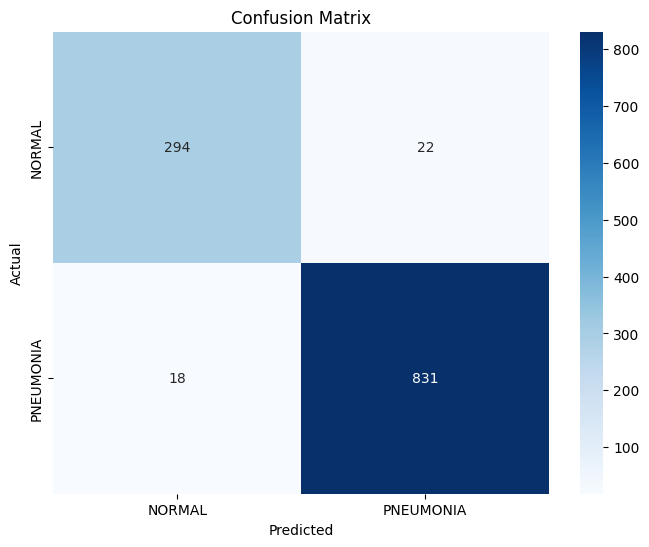

              precision    recall  f1-score   support

      NORMAL       0.94      0.93      0.94       316
   PNEUMONIA       0.97      0.98      0.98       849

    accuracy                           0.97      1165
   macro avg       0.96      0.95      0.96      1165
weighted avg       0.97      0.97      0.97      1165



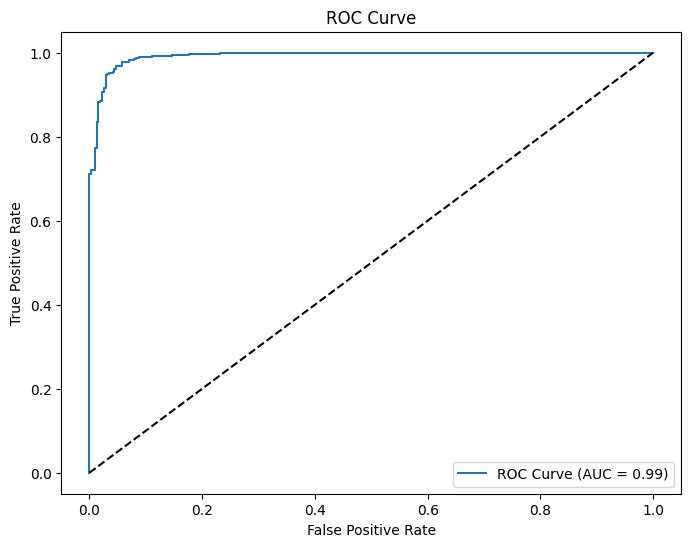

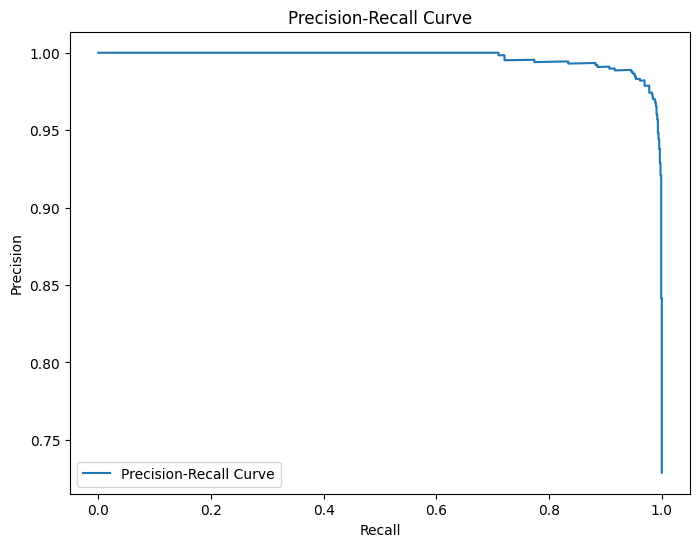

Best threshold for recall: 0.10, Recall: 0.9953
Model and config saved.


In [ ]:
#TODO: fix broken code
#TODO: decouple the val_loader

model.eval()

# Get predictions
all_preds = []
all_labels = []
all_probs = []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)[:,1]
        preds = (probs > 0.5).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

### Confusion Matrix

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Classification Report

In [ ]:
print(classification_report(all_labels, all_preds, target_names=CLASSES))

### ROC-AUC

In [ ]:
auc = roc_auc_score(all_labels, all_probs)
fpr, tpr, _ = roc_curve(all_labels, all_probs)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

### Precision-Recall Curve

In [ ]:
precision, recall, thresholds = precision_recall_curve(all_labels, all_probs)
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

### Threshold tuning for recall

In [ ]:
from sklearn.metrics import recall_score
best_threshold = 0.5
best_recall = 0
for thresh in np.arange(0.1, 0.9, 0.01):
    preds_thresh = (np.array(all_probs) > thresh).astype(int)
    rec = recall_score(all_labels, preds_thresh, pos_label=1)
    if rec > best_recall:
        best_recall = rec
        best_threshold = thresh

print(f'Best threshold for recall: {best_threshold:.2f}, Recall: {best_recall:.4f}')

In [ ]:
def predict(img_path:str):
	img= Image.open(img_path).convert('RGB')
	with torch.no_grad():
		probs = torch.softmax(model(preprocess(img).unsqueeze(0)), dim=1)[0]
	return {'class': config['classes'][probs.argmax()], 'confidence': float(probs.max()), 'probs': probs}

In [ ]:
import os
print(f'{'FILE': <32} {'CLASS': <16} CONFIDENCE')
for file in os.listdir('./test'):
	pred= predict(os.path.join('./test', file))
	print(f'{file: <32} {pred['class']: <16} {pred['confidence']}')